In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
import re

In [2]:
data = pd.read_csv("../data/Dataset.txt",sep="\t")
data.head()

,Age recode with <1 year olds and 90+,Sex,Year of diagnosis,"Race recode (W, B, AI, API)",Primary Site - labeled,Summary stage 2000 (1998-2017),Survival months,Vital status recode (study cutoff used),Median household income inflation adj to 2024
0,15-19 years,Male,2016,White,"C71.9-Brain, NOS",Localized,0091,Alive,"$110,000 - $119,999"
1,15-19 years,Male,2015,White,C71.2-Temporal lobe,Localized,0101,Alive,"$100,000 - $109,999"
2,10-14 years,Female,2013,White,C22.0-Liver,Regional,0122,Alive,"$100,000 - $109,999"
3,10-14 years,Male,2013,White,C73.9-Thyroid gland,Regional,0129,Alive,"$100,000 - $109,999"
4,15-19 years,Female,2021,White,C73.9-Thyroid gland,Blank(s),0031,Alive,"$120,000+"


In [3]:
data.info()                         

<class 'pandas.DataFrame'>
RangeIndex: 50603 entries, 0 to 50602
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Age recode with <1 year olds and 90+           50603 non-null  str  
 1   Sex                                            50603 non-null  str  
 2   Year of diagnosis                              50603 non-null  int64
 3   Race recode (W, B, AI, API)                    50603 non-null  str  
 4   Primary Site - labeled                         50603 non-null  str  
 5   Summary stage 2000 (1998-2017)                 50603 non-null  str  
 6   Survival months                                50603 non-null  str  
 7   Vital status recode (study cutoff used)        50603 non-null  str  
 8   Median household income inflation adj to 2024  50603 non-null  str  
dtypes: int64(1), str(8)
memory usage: 3.5 MB


In [4]:
data.describe()

,Year of diagnosis
count,50603.000000
mean,2017.422564
std,3.423367
min,2012.000000
25%,2014.000000
50%,2017.000000
75%,2020.000000
max,2023.000000


In [5]:
data.shape

(50603, 9)

In [6]:
data.columns = [
    "Age", "Sex", "Year", "Race", "Cancer_Type",
    "Stage", "Survival_Months", "Vital_Status", "Income"
]

In [7]:
data = data[data["Stage"] != "Blank(s)"]

In [8]:
data["Survival_Months"] = pd.to_numeric(data["Survival_Months"], errors="coerce")

In [9]:
data["Income"] = data["Income"].str.replace("$", "", regex=False)

In [10]:
def asignar_prioridad(row):
    stage = row["Stage"]
    survival = row["Survival_Months"]
    vital = row["Vital_Status"]

    if stage == "Distant":
        return "Alta"
    elif vital == "Dead" and survival < 36:
        return "Alta"
    elif stage == "Regional" and survival < 60:
        return "Alta"

    elif stage == "Regional":
        return "Media"
    elif stage in ["Localized", "In situ"] and survival < 60:
        return "Media"
    elif stage == "Unknown/unstaged":
        return "Media"
    else:
        return "Baja"

data["Prioridad"] = data.apply(asignar_prioridad, axis=1)

In [11]:
data["Prioridad"].value_counts()

Prioridad
Baja     6660
Media    4126
Alta     4031
Name: count, dtype: int64

In [12]:
data["Prioridad"].value_counts(normalize=True) * 100

Prioridad
Baja     44.948370
Media    27.846393
Alta     27.205237
Name: proportion, dtype: float64

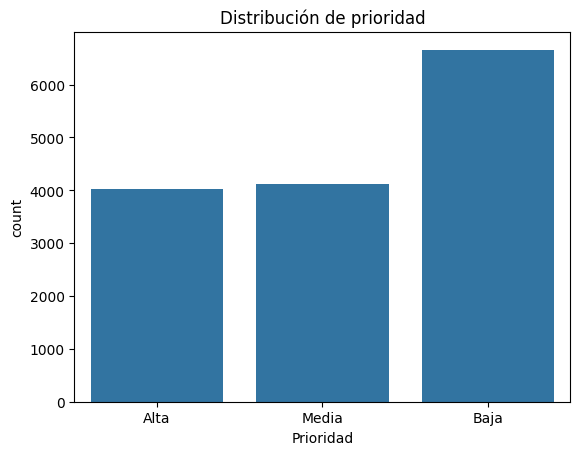

In [13]:
sns.countplot(data=data, x="Prioridad", order=["Alta", "Media", "Baja"])
plt.title("Distribución de prioridad")
plt.show()

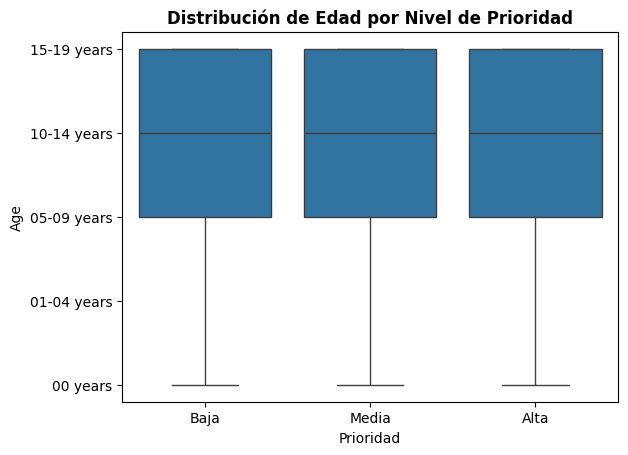

In [14]:
sns.boxplot(data=data, x="Prioridad", y="Age")
plt.title('Distribución de Edad por Nivel de Prioridad', fontsize=12, fontweight='bold')
plt.show()

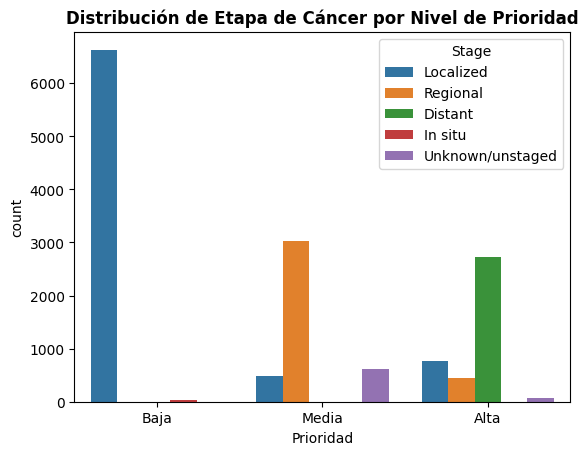

In [15]:
sns.countplot(data=data, x="Prioridad", hue="Stage")
plt.title('Distribución de Etapa de Cáncer por Nivel de Prioridad', fontsize=12, fontweight='bold')
plt.show()

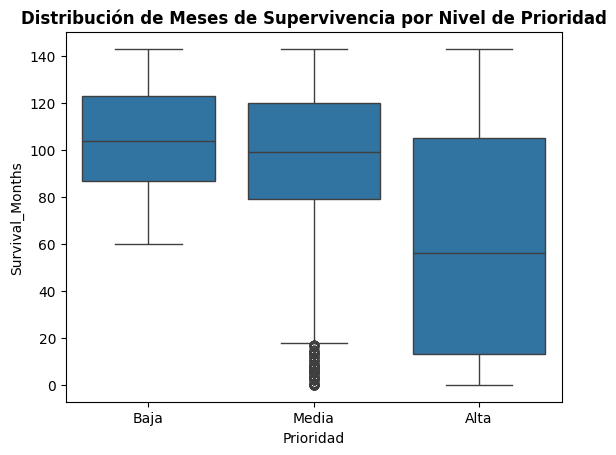

In [16]:
sns.boxplot(data=data, x="Prioridad", y="Survival_Months")
plt.title('Distribución de Meses de Supervivencia por Nivel de Prioridad', fontsize=12, fontweight='bold')
plt.show()

In [17]:
def agrupar_cancer(site):
    site = str(site)

    if "brain" in site.lower():
        return "Brain"
    elif "lung" in site.lower():
        return "Lung"
    elif "breast" in site.lower():
        return "Breast"
    elif "liver" in site.lower():
        return "Liver"
    elif "skin" in site.lower():
        return "Skin"
    elif "colon" in site.lower() or "rectum" in site.lower():
        return "Colorectal"
    else:
        return "Other"

data["Cancer_Group"] = data["Cancer_Type"].apply(agrupar_cancer)

In [18]:
data["Cancer_Type"] = data["Cancer_Type"].str.strip().str.lower()

In [19]:
data["Cancer_Type"].value_counts().head(20)

Cancer_Type
c73.9-thyroid gland                                           1455
c77.8-lymph nodes of multiple regions                         1295
c71.6-cerebellum, nos                                         1024
c64.9-kidney, nos                                              948
c71.7-brain stem                                               773
c77.0-lymph nodes of head, face & neck                         533
c62.1-descended testis                                         466
c18.1-appendix                                                 450
c71.9-brain, nos                                               446
c77.9-lymph node, nos                                          440
c56.9-ovary                                                    439
c22.0-liver                                                    411
c72.3-optic nerve                                              391
c62.9-testis, nos                                              344
c71.0-cerebrum                                    

In [20]:
top = data["Cancer_Type"].value_counts().head(10).index
data["Cancer_Group"] = data["Cancer_Type"].apply(
    lambda x: x if x in top else "Other"
)

print(top)

Index(['c73.9-thyroid gland', 'c77.8-lymph nodes of multiple regions',
       'c71.6-cerebellum, nos', 'c64.9-kidney, nos', 'c71.7-brain stem',
       'c77.0-lymph nodes of head, face & neck', 'c62.1-descended testis',
       'c18.1-appendix', 'c71.9-brain, nos', 'c77.9-lymph node, nos'],
      dtype='str', name='Cancer_Type')


In [21]:
X = data.drop(columns=["Prioridad", "Survival_Months", "Vital_Status"])
y = data["Prioridad"]

In [22]:
from sklearn.preprocessing import LabelEncoder

data_corr = data.copy()

le = LabelEncoder()

for col in data_corr.select_dtypes(include='object').columns:
    data_corr[col] = le.fit_transform(data_corr[col])

C:\Users\cance\AppData\Local\Temp\ipykernel_11664\4280875758.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data_corr.select_dtypes(include='object').columns:


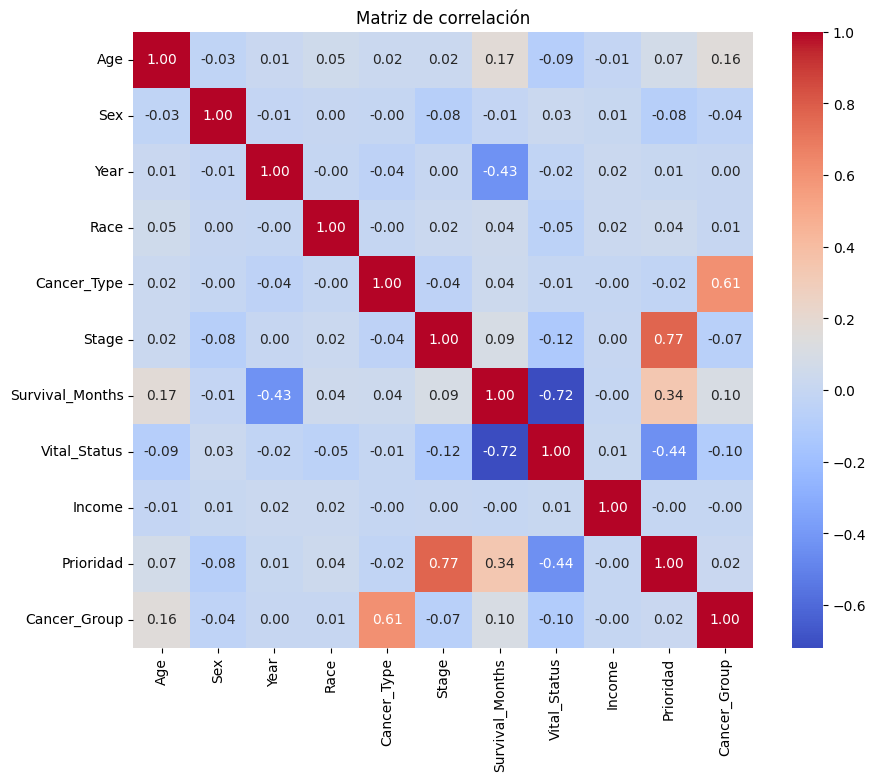

In [23]:
corr = data_corr.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [24]:
pd.crosstab(data["Stage"], data["Prioridad"], normalize="index")

Prioridad,Alta,Baja,Media
Stage,,,
Distant,1.000000,0.000000,0.000000
In situ,0.000000,0.965517,0.034483
Localized,0.098275,0.840984,0.060741
Regional,0.128065,0.000000,0.871935
Unknown/unstaged,0.112536,0.000000,0.887464


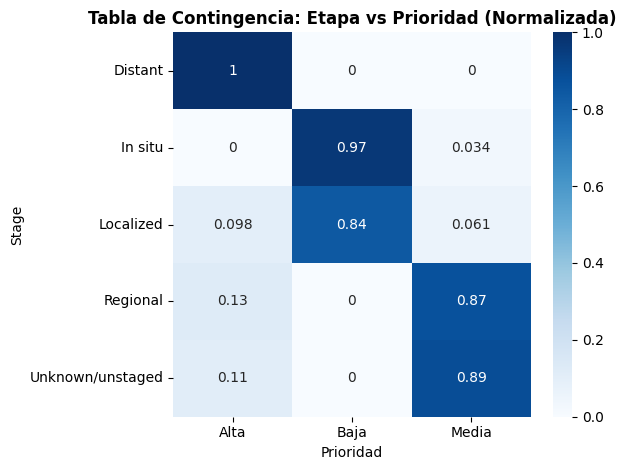

In [25]:
sns.heatmap(pd.crosstab(data["Stage"], data["Prioridad"], normalize="index"),
            annot=True, cmap="Blues")
plt.title('Tabla de Contingencia: Etapa vs Prioridad (Normalizada)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Valores Nulos y Duplicados
print("--- AUDITORÍA DE CALIDAD: EJE CLÍNICO ---")
print(f"Valores nulos por columna:\n{data.isnull().sum()}")
print(f"\nCantidad de filas duplicadas: {data.duplicated().sum()}")

--- AUDITORÍA DE CALIDAD: EJE CLÍNICO ---
Valores nulos por columna:
Age                 0
Sex                 0
Year                0
Race                0
Cancer_Type         0
Stage               0
Survival_Months    29
Vital_Status        0
Income              0
Prioridad           0
Cancer_Group        0
dtype: int64

Cantidad de filas duplicadas: 382


<Figure size 1000x600 with 0 Axes>

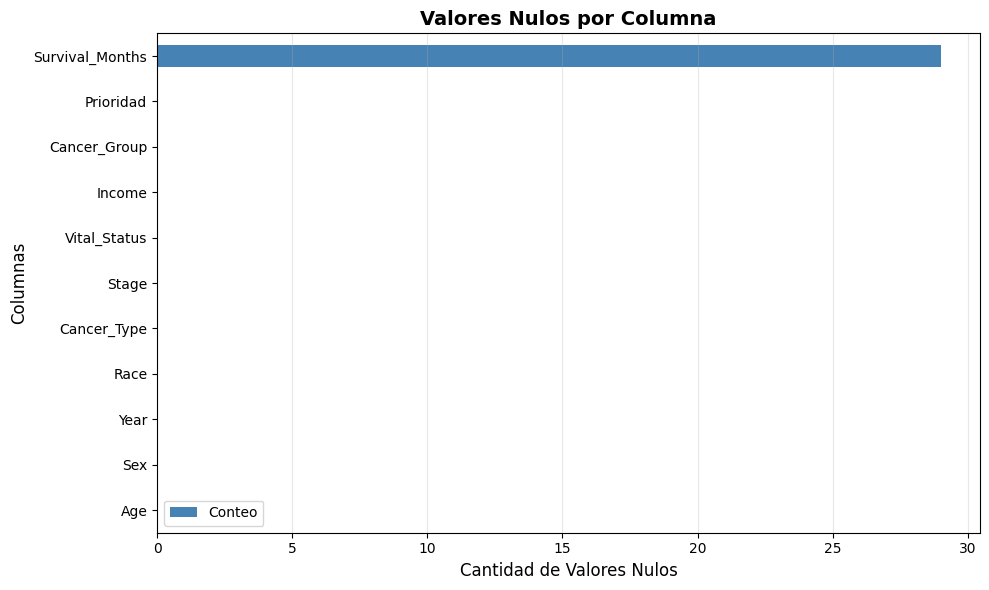

In [27]:
plt.figure(figsize=(10, 6))
missing_count = data.isnull().sum()
missing_data = pd.DataFrame({'Conteo': missing_count})
missing_data.sort_values('Conteo', ascending=True).plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Valores Nulos por Columna', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Valores Nulos', fontsize=12)
plt.ylabel('Columnas', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Convertir AGE
def convertir_age(valor):

    valor = str(valor)
    nums = re.findall(r'\d+', valor)

    if len(nums) >= 2:
        return (int(nums[0]) + int(nums[1])) / 2

    elif len(nums) == 1:
        return int(nums[0])

    return None

# Convertir INCOME
def convertir_income(valor):

    valor = str(valor)

    # Extraer números
    nums = re.findall(r'\d+', valor)

    # Unir miles separados
    nums = [n.replace(",", "") for n in nums]

    if len(nums) >= 2:

        inicio = int(nums[0] + nums[1]) if len(nums[0]) <= 3 else int(nums[0])

        if len(nums) >= 4:
            fin = int(nums[2] + nums[3])
        else:
            fin = int(nums[1])

        return (inicio + fin) / 2

    elif len(nums) == 1:
        return int(nums[0])

    return None

# Crear columnas numéricas
data["Age_num"] = data["Age"].apply(convertir_age)
data["Income_num"] = data["Income"].apply(convertir_income)


# Variables numéricas
num_vars = ["Age_num", "Income_num", "Year"]


# Prueba de normalidad
for col in num_vars:

    valores = data[col].dropna().astype(float)

    stat, p = shapiro(valores)

    print(f"\nVariable: {col}")
    print(f"Estadístico = {stat:.4f}")
    print(f"p-value = {p:.6f}")

    if p > 0.05:
        print("Distribución NORMAL")
    else:
        print("Distribución NO NORMAL")


Variable: Age_num
Estadístico = 0.8257
p-value = 0.000000
Distribución NO NORMAL

Variable: Income_num
Estadístico = 0.9735
p-value = 0.000000
Distribución NO NORMAL

Variable: Year
Estadístico = 0.9092
p-value = 0.000000
Distribución NO NORMAL


C:\Users\cance\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14817.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\cance\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14817.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\cance\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14817.
  res = hypotest_fun_out(*samples, **kwds)


                Age_num    Income_num         Year
Age_num       35.514478  2.607246e+03     0.146137
Income_num  2607.245855  3.388579e+08  2596.760721
Year           0.146137  2.596761e+03     2.860879


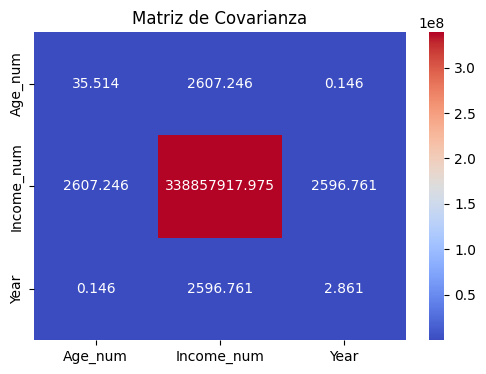

In [49]:
# Convertir AGE
def convertir_age(valor):

    valor = str(valor)
    nums = re.findall(r'\d+', valor)

    if len(nums) >= 2:
        return (int(nums[0]) + int(nums[1])) / 2

    elif len(nums) == 1:
        return int(nums[0])

    return None

# Convertir INCOME
def convertir_income(valor):

    valor = str(valor)

    # Extraer números
    nums = re.findall(r'\d+', valor)

    # Unir miles separados
    nums = [n.replace(",", "") for n in nums]

    if len(nums) >= 2:

        inicio = int(nums[0] + nums[1]) if len(nums[0]) <= 3 else int(nums[0])

        if len(nums) >= 4:
            fin = int(nums[2] + nums[3])
        else:
            fin = int(nums[1])

        return (inicio + fin) / 2

    elif len(nums) == 1:
        return int(nums[0])

    return None

# Crear columnas numéricas
data["Age_num"] = data["Age"].apply(convertir_age)
data["Income_num"] = data["Income"].apply(convertir_income)


num_vars = ["Age_num", "Income_num", "Year"]

cov_matrix = data[num_vars].cov()

print(cov_matrix)
plt.figure(figsize=(6,4))
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Matriz de Covarianza")
plt.show()

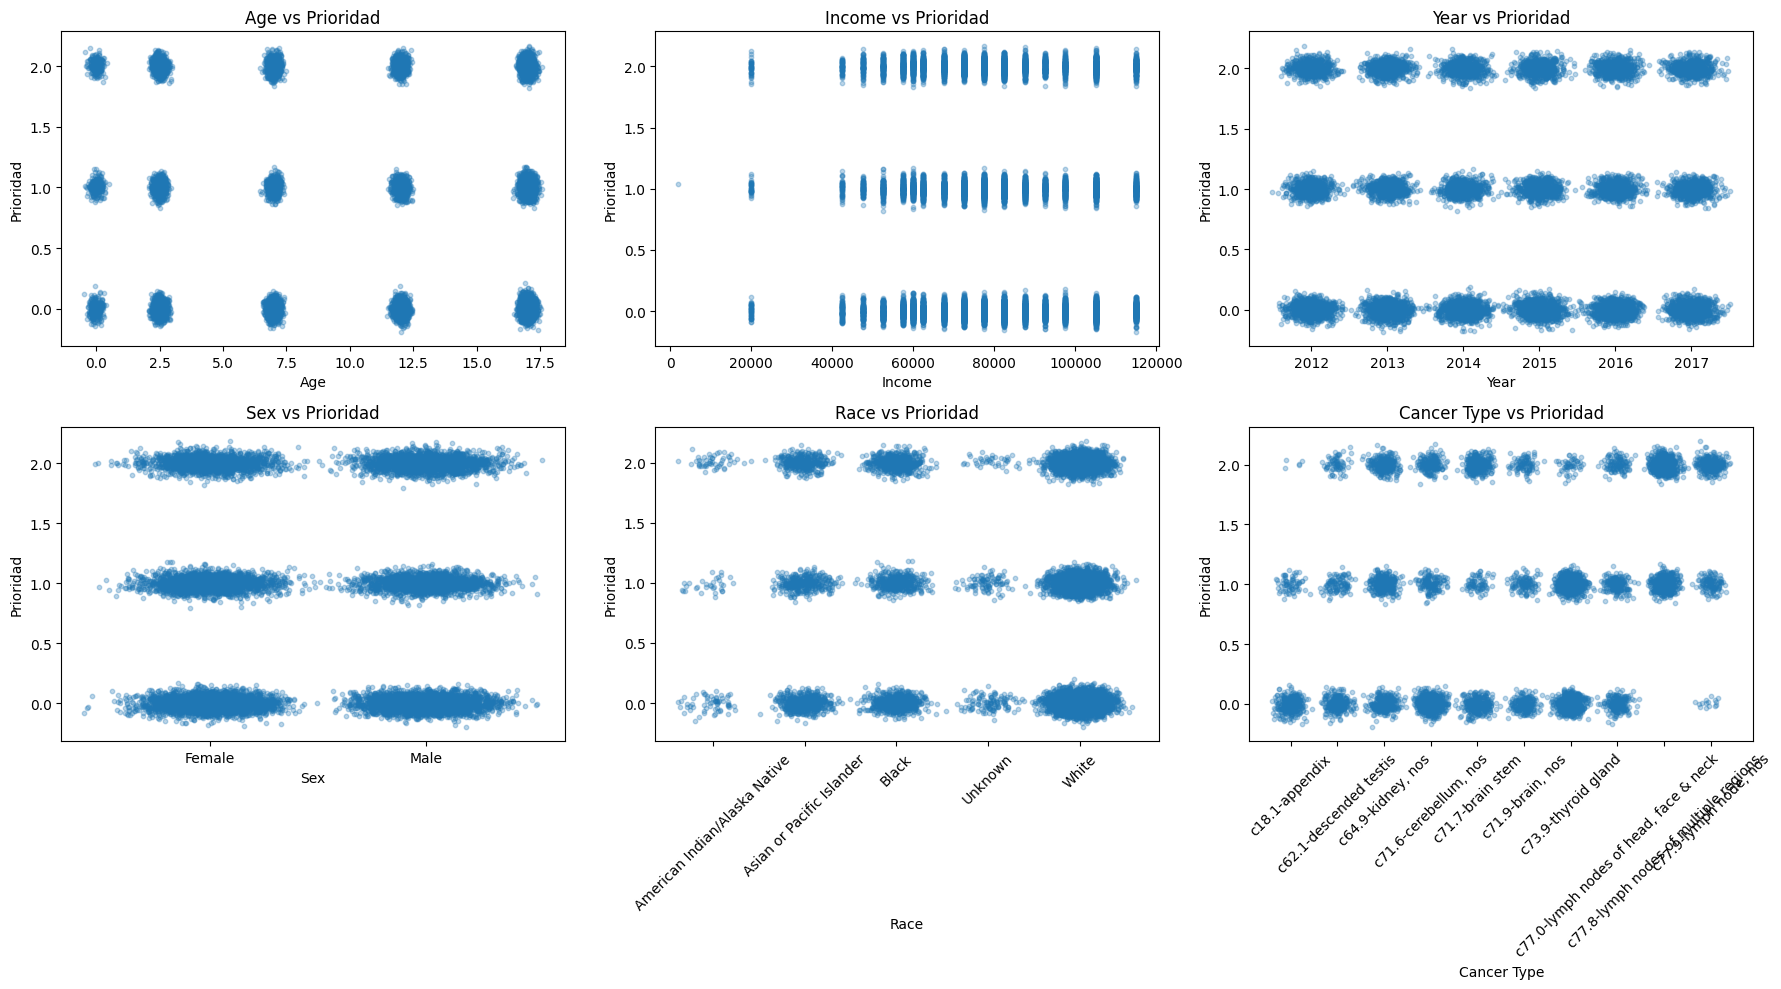

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

def scatter_jitter(ax, x, y, title, xlabel):
    x_jitter = x + np.random.normal(0, 0.15, size=len(x))
    y_jitter = y + np.random.normal(0, 0.05, size=len(y))
    ax.scatter(
        x_jitter,
        y_jitter,
        alpha=0.3,
        s=10
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Prioridad")

# NUMÉRICAS

scatter_jitter(
    axes[0,0],
    data["Age_num"],
    data["Prioridad_num"],
    "Age vs Prioridad",
    "Age"
)

scatter_jitter(
    axes[0,1],
    data["Income_num"],
    data["Prioridad_num"],
    "Income vs Prioridad",
    "Income"
)

scatter_jitter(
    axes[0,2],
    data["Year"],
    data["Prioridad_num"],
    "Year vs Prioridad",
    "Year"
)

# Convertir categóricas

sex_codes = data["Sex"].astype("category").cat.codes
race_codes = data["Race"].astype("category").cat.codes
cancer_codes = data["Cancer_Type"].astype("category").cat.codes

# SEX
sex_cat = data["Sex"].astype("category")
sex_codes = sex_cat.cat.codes

scatter_jitter(
    axes[1,0],
    sex_codes,
    data["Prioridad_num"],
    "Sex vs Prioridad",
    "Sex"
)

axes[1,0].set_xticks(range(len(sex_cat.cat.categories)))
axes[1,0].set_xticklabels(sex_cat.cat.categories)

# RACE
race_cat = data["Race"].astype("category")
race_codes = race_cat.cat.codes

scatter_jitter(
    axes[1,1],
    race_codes,
    data["Prioridad_num"],
    "Race vs Prioridad",
    "Race"
)

axes[1,1].set_xticks(range(len(race_cat.cat.categories)))
axes[1,1].set_xticklabels(
    race_cat.cat.categories,
    rotation=45
)

# CANCER TYPE
top_cancers = data["Cancer_Type"].value_counts().head(10).index

cancer_data = data[data["Cancer_Type"].isin(top_cancers)]

cancer_cat = cancer_data["Cancer_Type"].astype("category")
cancer_codes = cancer_cat.cat.codes

scatter_jitter(
    axes[1,2],
    cancer_codes,
    cancer_data["Prioridad_num"],
    "Cancer Type vs Prioridad",
    "Cancer Type"
)

axes[1,2].set_xticks(range(len(cancer_cat.cat.categories)))
axes[1,2].set_xticklabels(
    cancer_cat.cat.categories,
    rotation=45
)
plt.tight_layout()

# Mostrar
plt.show()

In [57]:
data = data.drop_duplicates()

promedio_survival = data["Survival_Months"].mean()

data["Survival_Months"] = data["Survival_Months"].fillna(promedio_survival)

print("Duplicados restantes:", data.duplicated().sum())

print("Nulos en Survival_Months:",
      data["Survival_Months"].isnull().sum())

print("Promedio usado:", promedio_survival)

Duplicados restantes: 0
Nulos en Survival_Months: 0
Promedio usado: 89.42142162987643


In [60]:
data_final = data[
    [
        "Age_num",
        "Income_num",
        "Year",
        "Sex",
        "Race",
        "Cancer_Type",
        "Prioridad"
    ]
]

data_final.to_csv("../data/data_limpia.csv",index=False)
